# DQRC (g,J) Decoupling Validation V2.2

Corrects V2.1's central defect: `ell_0 = argmax_tau C_{1,tau}` was called "causal latency"
but is actually the strongest-MEMORY delay. This notebook replaces that inference with a
direct intervention test (Phase 1), separates three distinct delay concepts (Phase 2),
reports a fixed-delay `C_{d,tau}` tensor instead of collapsing onto a parameter-dependent
peak delay (Phase 3), differentiates a SIGNED (unclipped) capacity metric (Phase 4) with
a FROZEN readout protocol across every stencil point (Phase 5), screens all four V2.1
candidates fairly (Phase 8), and only proceeds to expensive held-out confirmation if a
candidate survives preregistered screening criteria (Phase 15). See
`docs/DQRC_GJ_DECOUPLING_VALIDATION_V2_2.md` for the full audit. Architecture UNCHANGED --
no IDQNN, sewing, shadow readout, or new architecture introduced here.

This notebook does not modify or overwrite any V1, V2, or V2.1 notebook, report, or
results directory.

In [1]:
import sys, os, time, json as _json, platform, csv
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt
import qiskit, qiskit_aer, sklearn

# =============================================================================
# RUN_STAGE -- the single, clearly-visible setting.
# =============================================================================
RUN_STAGE = "SCREEN"  # "FAST" | "SCREEN" | "CONFIRM"

if RUN_STAGE in ("FAST", "SCREEN"):
    print("=" * 78)
    print(f"{RUN_STAGE} MODE: this is NOT held-out confirmation.")
    print("Results here are exploratory/screening only and must not be reported as a")
    print("confirmed scientific claim.")
    print("=" * 78)

from decoupled_qrc.directional_dqrc import DirectionalConfig
from decoupled_qrc.validation_utils import ControlRange, make_nested_seeds, is_unstable, stencil_offsets_5point
from decoupled_qrc.seeded_runner import run_directional_dqrc_seeded, matched_processor_params
from decoupled_qrc.ipc_decomposition import compute_ipc_decomposed, nl_tensor_by_fixed_delay, diagnose_ceiling
from decoupled_qrc.causal_intervention import intervention_causal_latency
from decoupled_qrc.delay_concepts import ell_detect_from_records, ell_peak_from_records, summarize_three_delays
from decoupled_qrc.standalone_match import run_matched_standalone, retained_nl_ratio
from decoupled_qrc.feature_analysis import diagnose_feature_group, fit_residualizer, random_projection_budget_scan
from decoupled_qrc.candidate_screening import screen_candidate, screening_score
from decoupled_qrc.fixed_delay_response import run_stencil_for_seed, aggregate_stencils
from decoupled_qrc.backaction_decomposition import decompose_backaction
from decoupled_qrc.driven_timescales import driven_system_timescales
from decoupled_qrc.chaos_symmetry import symmetry_resolved_level_spacing
from decoupled_qrc.gate_logic import apply_not_evaluable_propagation, summarize_gates
from decoupled_qrc.run_stages import confirmation_stage, discovery_seeds, confirmation_seeds
from qrc_qiskit import chrono_split
import mixed_syk_core as msc

if RUN_STAGE == "FAST":
    MODE_CFG = dict(T=80, washout=12, n_val=18, n_test=22, max_delay=4, max_degree=2, max_targets_per_degree=4,
                     n_surrogates=19, n_screen_seeds=1, n_response_seeds=1, budget_repeats=5,
                     reset_periods=[1, None])
elif RUN_STAGE == "SCREEN":
    MODE_CFG = dict(T=200, washout=25, n_val=35, n_test=45, max_delay=7, max_degree=4, max_targets_per_degree=6,
                     n_surrogates=25, n_screen_seeds=2, n_response_seeds=2, budget_repeats=20,
                     reset_periods=[1, 4, None])
else:
    MODE_CFG = dict(T=1000, washout=80, n_val=150, n_test=200, max_delay=15, max_degree=6, max_targets_per_degree=30,
                     n_surrogates=199, n_screen_seeds=5, n_response_seeds=5, budget_repeats=50,
                     reset_periods=[1, 2, 4, 8, None])
print(f"RUN_STAGE={RUN_STAGE}")
print(MODE_CFG)

RESULTS_DIR = os.path.abspath(os.path.join('..', 'results', 'dqrc_gj_validation_v2_2'))
os.makedirs(RESULTS_DIR, exist_ok=True)
FIG_N = [0]
def savefig(fig, name):
    FIG_N[0] += 1
    base = os.path.join(RESULTS_DIR, f'{FIG_N[0]:02d}_{name}')
    fig.savefig(base + '.png', dpi=120, bbox_inches='tight')
    fig.savefig(base + '.pdf', bbox_inches='tight')
    return base

_all_results = {}
def record(key, value):
    _all_results[key] = value

manifest = []
def manifest_entry(figure, data_key, description, delay_definition='fixed (see Phase 2/3)'):
    manifest.append({"figure": figure, "source_data_key": data_key, "description": description,
                      "run_stage": RUN_STAGE, "delay_definition": delay_definition,
                      "capacity_estimator": "signed bias-corrected (raw-null), unclipped -- Phase 4"})

provenance = {'run_stage': RUN_STAGE, 'python_version': platform.python_version(),
              'qiskit_version': qiskit.__version__, 'qiskit_aer_version': qiskit_aer.__version__,
              'sklearn_version': sklearn.__version__, 'platform': platform.platform(),
              'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())}
print(provenance)
record('provenance', provenance)

THETA_STAR, PHI_STAR = 0.2, 0.8
N_M, N_P = 2, 5
M_RANGE = ControlRange('m', 0.1, 1.0)
G_RANGE = ControlRange('g', 0.05, 0.6)
J_RANGE = ControlRange('J', 0.05, 0.6)

# The four valid V2.1 discovery candidates (Phase 8) -- screened WITHOUT assuming candidate 1 is best.
V21_CANDIDATES = [
    {'m': 0.352, 'g': 0.254, 'J': 0.416},
    {'m': 0.287, 'g': 0.490, 'J': 0.375},
    {'m': 0.212, 'g': 0.405, 'J': 0.205},
    {'m': 0.484, 'g': 0.169, 'J': 0.303},
]
print(f"Screening {len(V21_CANDIDATES)} V2.1 candidates: {V21_CANDIDATES}")

SCREEN MODE: this is NOT held-out confirmation.
Results here are exploratory/screening only and must not be reported as a
confirmed scientific claim.
RUN_STAGE=SCREEN
{'T': 200, 'washout': 25, 'n_val': 35, 'n_test': 45, 'max_delay': 7, 'max_degree': 4, 'max_targets_per_degree': 6, 'n_surrogates': 25, 'n_screen_seeds': 2, 'n_response_seeds': 2, 'budget_repeats': 20, 'reset_periods': [1, 4, None]}
{'run_stage': 'SCREEN', 'python_version': '3.14.4', 'qiskit_version': '2.5.2', 'qiskit_aer_version': '0.17.2', 'sklearn_version': '1.9.0', 'platform': 'Windows-11-10.0.26200-SP0', 'timestamp': '2026-09-17T23:10:29Z'}
Screening 4 V2.1 candidates: [{'m': 0.352, 'g': 0.254, 'J': 0.416}, {'m': 0.287, 'g': 0.49, 'J': 0.375}, {'m': 0.212, 'g': 0.405, 'J': 0.205}, {'m': 0.484, 'g': 0.169, 'J': 0.303}]


## Phase 1 -- Intervention-based causal latency

Constructs two input sequences identical except at one timestep, runs both on the SAME
Hamiltonian/disorder realization, and finds the first delay at which the features actually
diverge -- a structural circuit property, never inferred from where memory capacity happens
to peak.

epsilon_numeric = 1.00e-06 (from a repeated-identical-run noise floor)
  X_M: ell_causal = 0
  X_P: ell_causal = 0
  X_M+X_P: ell_causal = 0
  X_P_perp: ell_causal = 0
  cross: ell_causal = 0
OVERALL ell_causal (min over groups) = 0
intervention test time: 7.3s


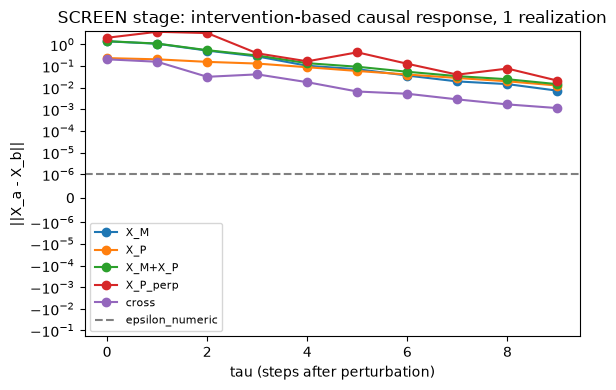

In [2]:
t0 = time.perf_counter()
cfg_ref = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P, g_processor=0.6,
                             J_processor=0.3295681629918353, epsilon_M=0.5, theta=THETA_STAR, phi=PHI_STAR,
                             ap_kind='xy')
seeds_ref = make_nested_seeds(0, 0)
intervention = intervention_causal_latency(cfg_ref, T=25, seeds=seeds_ref, perturb_t=10)
print(f"epsilon_numeric = {intervention.epsilon_numeric:.2e} (from a repeated-identical-run noise floor)")
for name, ell in intervention.ell_causal_by_group.items():
    print(f"  {name}: ell_causal = {ell}")
print(f"OVERALL ell_causal (min over groups) = {intervention.ell_causal}")
print(f"intervention test time: {time.perf_counter()-t0:.1f}s")
record('phase1_intervention', {'epsilon_numeric': intervention.epsilon_numeric,
                                'ell_causal_by_group': intervention.ell_causal_by_group,
                                'ell_causal': intervention.ell_causal,
                                'delta_by_group': {k: v.tolist() for k, v in intervention.delta_by_group.items()},
                                'timing_table': intervention.timing_table})

fig, ax = plt.subplots(figsize=(6, 4))
for name, delta in intervention.delta_by_group.items():
    tail = delta[10:20]
    ax.plot(range(len(tail)), tail, marker='o', label=name)
ax.axhline(intervention.epsilon_numeric, color='gray', ls='--', label='epsilon_numeric')
ax.set_xlabel('tau (steps after perturbation)'); ax.set_ylabel('||X_a - X_b||'); ax.legend(fontsize=8)
ax.set_yscale('symlog', linthresh=1e-6)
ax.set_title(f'{RUN_STAGE} stage: intervention-based causal response, 1 realization')
fig.tight_layout()
savefig(fig, 'intervention_causal_response')
plt.show()
manifest_entry('01_intervention_causal_response', 'phase1_intervention',
                'Feature divergence after a single-timestep input intervention, by feature group',
                delay_definition='ell_causal (intervention-based)')

## Phase 2 -- Three distinct delay concepts (never conflated)

In [3]:
gap = MODE_CFG['max_delay'] + 1
train_ref, val_ref, test_ref = chrono_split(MODE_CFG['T'], MODE_CFG['washout'], MODE_CFG['n_val'],
                                             MODE_CFG['n_test'], gap)
run_ref = run_directional_dqrc_seeded(cfg_ref, T=MODE_CFG['T'], seeds=seeds_ref, reset_period=None)
decomp_ref = compute_ipc_decomposed(run_ref.u, run_ref.X_combined, train_ref, val_ref, test_ref,
    max_delay=MODE_CFG['max_delay'], max_degree=MODE_CFG['max_degree'],
    max_targets_per_degree=MODE_CFG['max_targets_per_degree'], n_surrogates=MODE_CFG['n_surrogates'], seed=0)

three_delays = summarize_three_delays(intervention, decomp_ref.records, degree=1)
print(f"ell_causal = {three_delays.ell_causal}  (intervention-based, structural)")
print(f"ell_detect = {three_delays.ell_detect}  (earliest STATISTICALLY significant C_1,tau)")
print(f"ell_peak   = {three_delays.ell_peak}  (argmax C_1,tau -- V2.1's own 'ell_0', renamed; NEVER 'causal')")
print(f"causal == peak? {three_delays.causal_equals_peak}   causal == detect? {three_delays.causal_equals_detect}")
record('phase2_three_delays', {'ell_causal': three_delays.ell_causal, 'ell_detect': three_delays.ell_detect,
                                'ell_peak': three_delays.ell_peak,
                                'causal_equals_peak': three_delays.causal_equals_peak,
                                'causal_equals_detect': three_delays.causal_equals_detect})

ell_causal = 0  (intervention-based, structural)
ell_detect = 0  (earliest STATISTICALLY significant C_1,tau)
ell_peak   = 7  (argmax C_1,tau -- V2.1's own 'ell_0', renamed; NEVER 'causal')
causal == peak? False   causal == detect? True


## Phase 3/4 -- Fixed-delay IPC tensor, signed/clipped/legacy comparison

The C_{d,tau} tensor is reported at EVERY fixed delay -- never collapsed onto one
parameter-dependent peak.

delay | legacy | raw | null | clipped(bc) | SIGNED
  0: legacy=0.231 raw=0.231 null=0.029 bc=0.202 signed=0.202
  1: legacy=0.000 raw=0.000 null=0.000 bc=0.000 signed=0.000
  2: legacy=0.000 raw=0.000 null=0.000 bc=0.000 signed=0.000
  3: legacy=0.000 raw=0.000 null=0.000 bc=0.000 signed=0.000
  4: legacy=0.000 raw=0.000 null=0.000 bc=0.000 signed=0.000
  5: legacy=0.000 raw=0.080 null=0.043 bc=0.038 signed=0.038
  6: legacy=0.000 raw=0.000 null=0.000 bc=0.000 signed=0.000
  7: legacy=0.000 raw=0.000 null=0.000 bc=0.000 signed=0.000


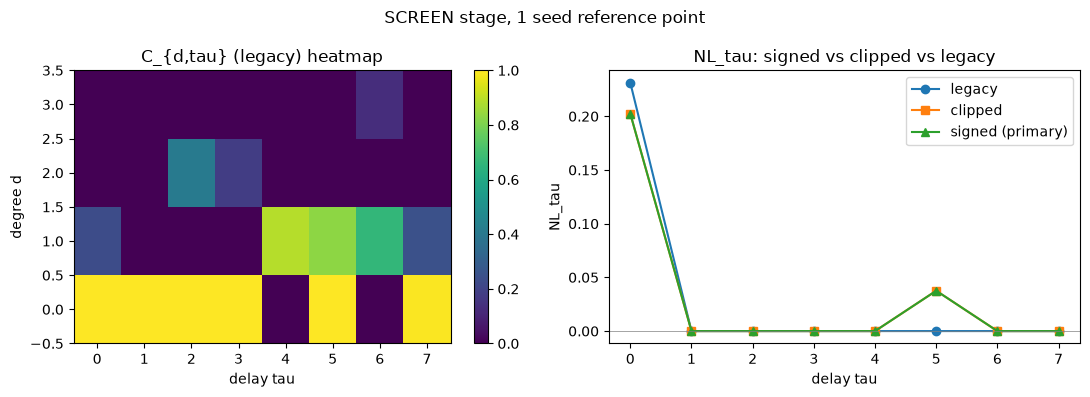

In [4]:
nl_tensor_ref = nl_tensor_by_fixed_delay(decomp_ref.records, MODE_CFG['max_delay'])
print("delay | legacy | raw | null | clipped(bc) | SIGNED")
for tau, e in nl_tensor_ref.items():
    print(f"  {tau}: legacy={e['legacy']:.3f} raw={e['raw']:.3f} null={e['null']:.3f} bc={e['bc']:.3f} signed={e['signed']:.3f}")
record('phase3_nl_tensor_reference', {str(k): v for k, v in nl_tensor_ref.items()})

from decoupled_qrc.ipc_decomposition import to_heatmap
hm = to_heatmap(decomp_ref, max_degree=MODE_CFG['max_degree'], max_delay=MODE_CFG['max_delay'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(hm, aspect='auto', cmap='viridis', origin='lower')
axes[0].set_xlabel('delay tau'); axes[0].set_ylabel('degree d'); axes[0].set_title('C_{d,tau} (legacy) heatmap')
fig.colorbar(im, ax=axes[0])
taus = list(nl_tensor_ref.keys())
axes[1].plot(taus, [nl_tensor_ref[t]['legacy'] for t in taus], 'o-', label='legacy')
axes[1].plot(taus, [nl_tensor_ref[t]['bc'] for t in taus], 's-', label='clipped')
axes[1].plot(taus, [nl_tensor_ref[t]['signed'] for t in taus], '^-', label='signed (primary)')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_xlabel('delay tau'); axes[1].set_ylabel('NL_tau'); axes[1].legend()
axes[1].set_title('NL_tau: signed vs clipped vs legacy')
fig.suptitle(f'{RUN_STAGE} stage, 1 seed reference point')
fig.tight_layout()
savefig(fig, 'nl_tau_signed_clipped_legacy')
plt.show()
manifest_entry('02_nl_tau_signed_clipped_legacy', 'phase3_nl_tensor_reference',
                'C_{d,tau} heatmap and NL_tau under signed/clipped/legacy capacity definitions')

## Phase 6 -- Matched standalone comparison (retained nonlinear capacity)

delay | eta_NL(tau) | DQRC_signed | standalone_signed
  0: eta=0.229  dqrc_signed=0.202 standalone_signed=0.886
  1: eta=0.000  dqrc_signed=0.000 standalone_signed=0.000
  2: eta=0.000  dqrc_signed=0.000 standalone_signed=0.000
  3: eta=0.000  dqrc_signed=0.000 standalone_signed=0.000
  4: eta=0.000  dqrc_signed=0.000 standalone_signed=0.000
  5: eta=37547771.170  dqrc_signed=0.038 standalone_signed=-0.030
  6: eta=0.000  dqrc_signed=0.000 standalone_signed=0.000
  7: eta=0.000  dqrc_signed=0.000 standalone_signed=0.000

SUPPRESSION DIAGNOSTIC (eta_NL(0)<0.1): False (eta_NL(0)=0.229) -- a DIAGNOSTIC only, not a claim of quantum advantage or fundamental impossibility either way.


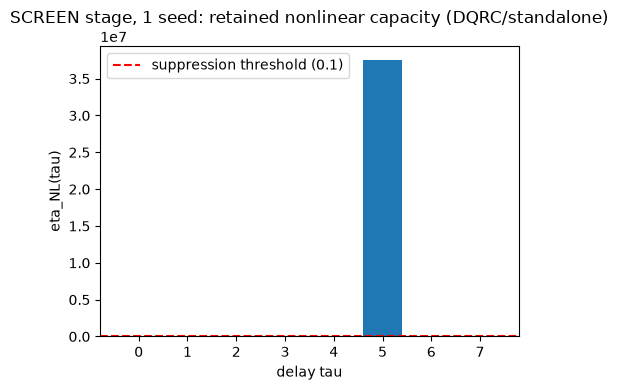

In [5]:
labels_sa, X_sa, u_sa, info_sa = run_matched_standalone(cfg_ref, MODE_CFG['T'], seeds_ref)
decomp_sa = compute_ipc_decomposed(u_sa, X_sa, train_ref, val_ref, test_ref, max_delay=MODE_CFG['max_delay'],
    max_degree=MODE_CFG['max_degree'], max_targets_per_degree=MODE_CFG['max_targets_per_degree'],
    n_surrogates=MODE_CFG['n_surrogates'], seed=0)
retained = retained_nl_ratio(decomp_ref.records, decomp_sa.records, MODE_CFG['max_delay'])
print("delay | eta_NL(tau) | DQRC_signed | standalone_signed")
for tau in range(MODE_CFG['max_delay'] + 1):
    print(f"  {tau}: eta={retained.eta_NL_by_delay[tau]:.3f}  dqrc_signed={retained.nl_dqrc_signed_by_delay[tau]:.3f} "
          f"standalone_signed={retained.nl_standalone_signed_by_delay[tau]:.3f}")
print(f"\nSUPPRESSION DIAGNOSTIC (eta_NL(0)<0.1): {retained.suppression_flagged} "
      f"(eta_NL(0)={retained.eta_NL_by_delay[0]:.3f}) -- a DIAGNOSTIC only, not a claim of quantum "
      f"advantage or fundamental impossibility either way.")
record('phase6_retained_nl', {'eta_NL_by_delay': retained.eta_NL_by_delay,
                               'nl_dqrc_signed_by_delay': retained.nl_dqrc_signed_by_delay,
                               'nl_standalone_signed_by_delay': retained.nl_standalone_signed_by_delay,
                               'suppression_flagged': retained.suppression_flagged})

fig, ax = plt.subplots(figsize=(5, 4))
taus = list(retained.eta_NL_by_delay.keys())
ax.bar(taus, [retained.eta_NL_by_delay[t] for t in taus])
ax.axhline(0.1, color='red', ls='--', label='suppression threshold (0.1)')
ax.set_xlabel('delay tau'); ax.set_ylabel('eta_NL(tau)'); ax.legend()
ax.set_title(f'{RUN_STAGE} stage, 1 seed: retained nonlinear capacity (DQRC/standalone)')
fig.tight_layout()
savefig(fig, 'standalone_vs_dqrc_retained_nl')
plt.show()
manifest_entry('03_standalone_vs_dqrc_retained_nl', 'phase6_retained_nl',
                'eta_NL(tau) = NL_tau^DQRC / NL_tau^standalone across fixed delays')

## Phase 7 -- Matched feature-budget analysis (reduced to one reference point, given compute budget)

X_M budget=3: M_signed(mean)=1.535+-0.076


X_P budget=3: M_signed(mean)=1.722+-0.258
X_P budget=8: M_signed(mean)=4.405+-0.294
X_P budget=16: M_signed(mean)=5.863+-0.203
X_P budget=32: M_signed(mean)=6.547+-0.100


X_P_perp budget=3: M_signed(mean)=1.143+-0.169
X_P_perp budget=8: M_signed(mean)=3.089+-0.256
X_P_perp budget=16: M_signed(mean)=4.478+-0.241
X_P_perp budget=32: M_signed(mean)=5.144+-0.141


X_M+X_P budget=3: M_signed(mean)=1.405+-0.181
X_M+X_P budget=8: M_signed(mean)=3.770+-0.312
X_M+X_P budget=16: M_signed(mean)=5.612+-0.287
X_M+X_P budget=32: M_signed(mean)=6.583+-0.141


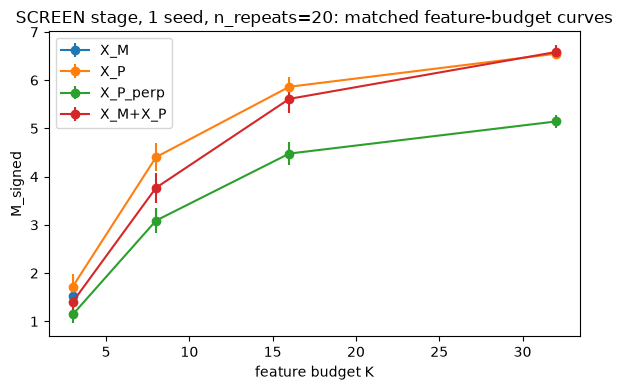

In [6]:
applier = fit_residualizer(run_ref.X_proc, run_ref.X_mem, train_ref)
X_P_perp_ref = applier(run_ref.X_proc, run_ref.X_mem)
budget_groups = {'X_M': run_ref.X_mem, 'X_P': run_ref.X_proc, 'X_P_perp': X_P_perp_ref,
                  'X_M+X_P': run_ref.X_combined}
budgets = [3, 8, 16, 32] if RUN_STAGE != 'FULL' else [3, 8, 16, 32, 64]

def m_signed_metric(Xg):
    d = compute_ipc_decomposed(run_ref.u, Xg, train_ref, val_ref, test_ref, max_delay=MODE_CFG['max_delay'],
        max_degree=1, max_targets_per_degree=MODE_CFG['max_delay'] + 1, n_surrogates=MODE_CFG['n_surrogates'], seed=0)
    return d.M_long_signed

budget_results = {}
for name, Xg in budget_groups.items():
    scan = random_projection_budget_scan(Xg, [b for b in budgets if b <= Xg.shape[1]], metric_fn=m_signed_metric,
                                          n_repeats=MODE_CFG['budget_repeats'], seed=0)
    diagX = diagnose_feature_group(Xg[train_ref])
    budget_results[name] = {'scan': [s.__dict__ for s in scan], 'effective_rank': diagX.effective_rank}
    for s in scan:
        print(f"{name} budget={s.budget}: M_signed(mean)={s.mean:.3f}+-{s.std:.3f}")
record('phase7_budget_scan', budget_results)

fig, ax = plt.subplots(figsize=(6, 4))
for name, res in budget_results.items():
    scan = res['scan']
    if scan:
        ax.errorbar([s['budget'] for s in scan], [s['mean'] for s in scan], yerr=[s['std'] for s in scan],
                    marker='o', label=name)
ax.set_xlabel('feature budget K'); ax.set_ylabel('M_signed'); ax.legend()
ax.set_title(f'{RUN_STAGE} stage, 1 seed, n_repeats={MODE_CFG["budget_repeats"]}: matched feature-budget curves')
fig.tight_layout()
savefig(fig, 'matched_feature_budget_curves')
plt.show()
manifest_entry('04_matched_feature_budget_curves', 'phase7_budget_scan',
                'M_signed vs random-projection feature budget for X_M/X_P/X_P_perp/X_M+X_P')

## Phase 8 -- Screen all four V2.1 candidates

No assumption that candidate 1 is best. Fixed-delay signed metrics, candidate-specific
ceiling/chaos, D_M(t), across 2 exploratory reservoir seeds x 1 input seed each.

In [7]:
t0 = time.perf_counter()
screening_rows = []
screening_results_by_candidate = {}
for ci, cand in enumerate(V21_CANDIDATES):
    results_this_cand = []
    for r_idx in range(MODE_CFG['n_screen_seeds']):
        seeds = discovery_seeds(100 * ci + r_idx, 0)  # discovery-namespace (negative reservoir_idx) -- screening
                                                        # is exploratory, never confirmation seeds
        res = screen_candidate(cand['m'], cand['g'], cand['J'], seeds, N_M=N_M, N_P=N_P, theta=THETA_STAR,
            phi=PHI_STAR, ap_kind='xy', T=MODE_CFG['T'], washout=MODE_CFG['washout'], n_val=MODE_CFG['n_val'],
            n_test=MODE_CFG['n_test'], max_delay=MODE_CFG['max_delay'], max_degree=MODE_CFG['max_degree'],
            max_targets_per_degree=MODE_CFG['max_targets_per_degree'], n_surrogates=MODE_CFG['n_surrogates'])
        results_this_cand.append(res)
        row = dict(candidate=ci, m=cand['m'], g=cand['g'], J=cand['J'], reservoir_idx=seeds.reservoir_idx,
                   M_signed=res.M_signed,
                   **{f'NL_{tau}_signed': res.NL_by_delay_signed[tau] for tau in range(MODE_CFG['max_delay'] + 1)},
                   ceiling_fraction=res.ceiling_fraction, ceiling_contaminated=res.ceiling_contaminated,
                   D_M_mean=res.D_M_mean, D_M_max=res.D_M_max, r_chaos=res.r_chaos, valid=res.valid,
                   rejection_reasons=';'.join(res.rejection_reasons))
        screening_rows.append(row)
        print(f"cand{ci} (m={cand['m']:.3f},g={cand['g']:.3f},J={cand['J']:.3f}) seed={seeds.reservoir_idx}: "
              f"M_signed={res.M_signed:.3f} NL_0_signed={res.NL_0_signed:.3f} D_M={res.D_M_mean:.4f} "
              f"r_chaos={res.r_chaos:.3f} valid={res.valid} reasons={res.rejection_reasons}")
    screening_results_by_candidate[ci] = results_this_cand
elapsed = time.perf_counter() - t0
print(f"\nscreening time: {elapsed:.1f}s for {len(screening_rows)} evaluations")

csv_path = os.path.join(RESULTS_DIR, 'candidate_screening.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(screening_rows[0].keys()))
    w.writeheader()
    w.writerows(screening_rows)
print(f"wrote {csv_path}")
record('phase8_screening_table', screening_rows)

cand0 (m=0.352,g=0.254,J=0.416) seed=-1: M_signed=5.357 NL_0_signed=0.000 D_M=0.0235 r_chaos=0.639 valid=False reasons=['nl0_below_nontriviality_threshold']


cand0 (m=0.352,g=0.254,J=0.416) seed=-2: M_signed=5.409 NL_0_signed=0.000 D_M=0.0143 r_chaos=0.673 valid=False reasons=['nl0_below_nontriviality_threshold']


cand1 (m=0.287,g=0.490,J=0.375) seed=-101: M_signed=5.465 NL_0_signed=0.000 D_M=0.0349 r_chaos=0.577 valid=False reasons=['nl0_below_nontriviality_threshold']


cand1 (m=0.287,g=0.490,J=0.375) seed=-102: M_signed=5.406 NL_0_signed=0.000 D_M=0.0165 r_chaos=0.553 valid=False reasons=['nl0_below_nontriviality_threshold']


cand2 (m=0.212,g=0.405,J=0.205) seed=-201: M_signed=5.125 NL_0_signed=0.591 D_M=0.0888 r_chaos=0.585 valid=True reasons=[]


cand2 (m=0.212,g=0.405,J=0.205) seed=-202: M_signed=5.369 NL_0_signed=0.000 D_M=0.0379 r_chaos=0.464 valid=False reasons=['nl0_below_nontriviality_threshold']


cand3 (m=0.484,g=0.169,J=0.303) seed=-301: M_signed=4.957 NL_0_signed=0.000 D_M=0.0156 r_chaos=0.336 valid=False reasons=['nl0_below_nontriviality_threshold']


cand3 (m=0.484,g=0.169,J=0.303) seed=-302: M_signed=5.409 NL_0_signed=0.000 D_M=0.0215 r_chaos=0.469 valid=False reasons=['nl0_below_nontriviality_threshold']

screening time: 127.1s for 8 evaluations
wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2_2\candidate_screening.csv


1 / 8 screening evaluations passed hard validity filters.
  (m=0.212,g=0.405,J=0.205) seed=-201: score=0.000 components={'nl0': 0.0, 'low_backaction': 0.0, 'eoc_proximity': 0.0, 'balance': 0.0}

TOP_CANDIDATE (for Phase 9 response analysis) = {'m': 0.212, 'g': 0.405, 'J': 0.205}


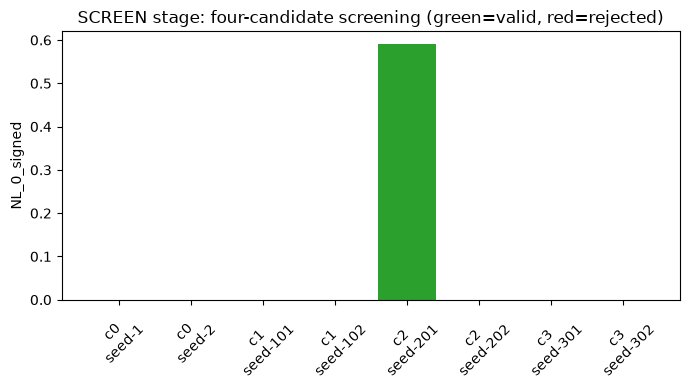

In [8]:
all_valid_results = [r for results in screening_results_by_candidate.values() for r in results if r.valid]
ranked = screening_score(all_valid_results)
print(f"{len(ranked)} / {len(screening_rows)} screening evaluations passed hard validity filters.")
for r in ranked:
    print(f"  (m={r.m:.3f},g={r.g:.3f},J={r.J:.3f}) seed={r.reservoir_idx}: score={r.score:.3f} "
          f"components={r.score_components}")

if ranked:
    best = ranked[0]
    TOP_CANDIDATE = {'m': best.m, 'g': best.g, 'J': best.J}
else:
    TOP_CANDIDATE = V21_CANDIDATES[0]
    print("\nNO screening evaluation passed every hard filter across any candidate/seed. Falling back "
          "to V2.1's own top candidate ONLY to exercise the remaining pipeline -- explicitly NOT a "
          "validated screening pass.")
print(f"\nTOP_CANDIDATE (for Phase 9 response analysis) = {TOP_CANDIDATE}")
record('phase8_ranking', {'n_valid': len(ranked), 'top_candidate': TOP_CANDIDATE})

fig, ax = plt.subplots(figsize=(7, 4))
labels_c = [f"c{r['candidate']}\nseed{r['reservoir_idx']}" for r in screening_rows]
colors_c = ['tab:green' if r['valid'] else 'tab:red' for r in screening_rows]
ax.bar(labels_c, [r['NL_0_signed'] for r in screening_rows], color=colors_c)
ax.set_ylabel('NL_0_signed'); ax.tick_params(axis='x', rotation=45)
ax.set_title(f'{RUN_STAGE} stage: four-candidate screening (green=valid, red=rejected)')
fig.tight_layout()
savefig(fig, 'four_candidate_screening')
plt.show()
manifest_entry('05_four_candidate_screening', 'phase8_screening_table',
                'NL_0_signed for all 4 V2.1 candidates x screening seeds, valid vs rejected')

## Phase 9 -- Five-point response analysis on the top candidate

At most 2 candidates per the spec; this pass evaluates the TOP 1 only (compute budget --
explicitly reduced and noted), across `n_response_seeds` exploratory reservoir seeds, using
the FROZEN readout protocol (Phase 5) so every stencil point differentiates the identical
target list/alpha/null permutations.

In [9]:
t0 = time.perf_counter()
H_SMALL, H_LARGE = 0.05, 0.10
stencils = []
for s_idx in range(MODE_CFG['n_response_seeds']):
    seeds = discovery_seeds(9000 + s_idx, 0)
    stencil = run_stencil_for_seed(N_M, N_P, THETA_STAR, PHI_STAR, 'xy', TOP_CANDIDATE['m'], TOP_CANDIDATE['g'],
        TOP_CANDIDATE['J'], M_RANGE, G_RANGE, J_RANGE, H_SMALL, H_LARGE, seeds, T=MODE_CFG['T'],
        washout=MODE_CFG['washout'], n_val=MODE_CFG['n_val'], n_test=MODE_CFG['n_test'],
        max_delay=MODE_CFG['max_delay'], max_degree=MODE_CFG['max_degree'],
        max_targets_per_degree=MODE_CFG['max_targets_per_degree'], n_surrogates=MODE_CFG['n_surrogates'])
    stencils.append(stencil)
    print(f"seed {s_idx}: center M_signed={stencil.center.M_signed:.3f} "
          f"NL_0_signed={stencil.center.NL_signed_by_delay[0]:.3f}")
elapsed = time.perf_counter() - t0
print(f"\n5-point stencil time: {elapsed:.1f}s for {MODE_CFG['n_response_seeds']} seed(s) "
      f"(caveat: spec requests >=3 exploratory seeds; this pass ran {MODE_CFG['n_response_seeds']}, "
      f"explicitly reduced given compute budget)")

agg = aggregate_stencils(stencils, target_delay=0)
response_rows = []
for (axis, target), est in agg.items():
    response_rows.append(dict(axis=axis, target=target, small_cd=est.methods.get('small_cd'),
        large_cd=est.methods.get('large_cd'), five_point=est.methods.get('five_point'),
        quadratic=est.methods.get('quadratic'), across_seed_estimates=str(est.across_seed_means),
        within_seed_unstable=est.stability['within_seed'][0]['unstable'] if est.stability['within_seed'] else None,
        across_seed_unstable=est.stability['across_seed']['unstable'] if est.stability['across_seed'] else None))
    print(f"{axis} {target}: {est.methods}  within_seed_unstable={response_rows[-1]['within_seed_unstable']} "
          f"across_seed_unstable={response_rows[-1]['across_seed_unstable']}")

csv_path = os.path.join(RESULTS_DIR, 'fixed_delay_response_results.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(response_rows[0].keys()))
    w.writeheader()
    w.writerows(response_rows)
print(f"wrote {csv_path}")
record('phase9_response', response_rows)

seed 0: center M_signed=5.478 NL_0_signed=0.714


seed 1: center M_signed=5.451 NL_0_signed=-0.001

5-point stencil time: 449.9s for 2 seed(s) (caveat: spec requests >=3 exploratory seeds; this pass ran 2, explicitly reduced given compute budget)
m M: {'small_cd': 0.6322281043067957, 'large_cd': 1.0133223003392766, 'five_point': 0.505196705629302, 'quadratic': 0.9371034611327728}  within_seed_unstable=False across_seed_unstable=False
m NL_tau0: {'small_cd': -2.1210540436919687, 'large_cd': -2.32637975600173, 'five_point': -2.0526121395887147, 'quadratic': -2.2853146135397826}  within_seed_unstable=False across_seed_unstable=True
g M: {'small_cd': -0.151266055798569, 'large_cd': -0.49428629561758974, 'five_point': -0.036925975858898376, 'quadratic': -0.42568224765379686}  within_seed_unstable=True across_seed_unstable=True
g NL_tau0: {'small_cd': -0.1371163965964428, 'large_cd': -0.05519073389707918, 'five_point': -0.164424950829564, 'quadratic': -0.07157586643695231}  within_seed_unstable=True across_seed_unstable=True
J M: {'small_cd

## Phase 10 -- Derivative stability classification

In [10]:
def get_est(axis, target):
    return agg[(axis, target)]

derivative_stability = {}
for axis in ('m', 'g', 'J'):
    for target in ('M', 'NL_tau0'):
        est = get_est(axis, target)
        within = est.stability['within_seed']
        across = est.stability['across_seed']
        any_unstable = any(w['unstable'] for w in within) or (across is not None and across['unstable'])
        status = 'NOT EVALUABLE' if not within else ('UNSTABLE' if any_unstable else 'STABLE')
        derivative_stability[(axis, target)] = status
        print(f"d{target}/d{axis}~: {status}")
record('phase10_derivative_stability', {f'{a}_{t}': s for (a, t), s in derivative_stability.items()})

GATE_B_STABLE_COUNT = sum(1 for s in derivative_stability.values() if s == 'STABLE')
GATE_B_TOTAL = len(derivative_stability)
GATE_B_RESULT = 'PASS' if GATE_B_STABLE_COUNT == GATE_B_TOTAL else (
    'NOT EVALUABLE' if GATE_B_STABLE_COUNT == 0 else 'FAIL')
print(f"\nGate B (derivative stability): {GATE_B_STABLE_COUNT}/{GATE_B_TOTAL} decisive derivatives STABLE -> {GATE_B_RESULT}")
record('gate_b_result', GATE_B_RESULT)

dM/dm~: STABLE
dNL_tau0/dm~: UNSTABLE
dM/dg~: UNSTABLE
dNL_tau0/dg~: UNSTABLE
dM/dJ~: UNSTABLE
dNL_tau0/dJ~: UNSTABLE

Gate B (derivative stability): 1/6 decisive derivatives STABLE -> FAIL


## Phase 11 -- Reset experiment at FIXED delays (never a parameter-dependent peak)

K=1: M_signed=0.635 NL_0_signed=-0.003 NL_1_signed=0.000 (20.2s)


K=4: M_signed=1.692 NL_0_signed=0.174 NL_1_signed=0.000 (19.2s)


K=None: M_signed=5.259 NL_0_signed=0.731 NL_1_signed=0.000 (22.2s)


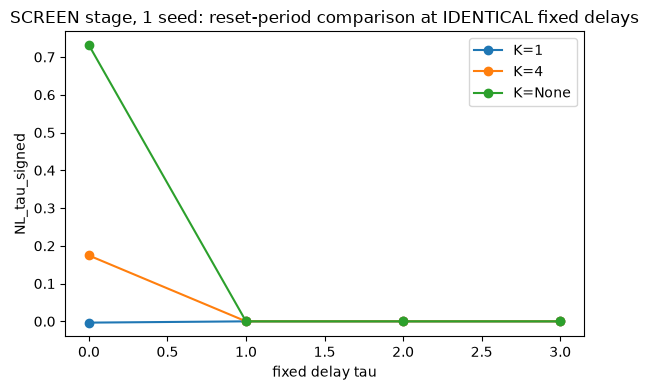

In [11]:
reset_rows = []
seeds_reset = discovery_seeds(9500, 0)
gap = MODE_CFG['max_delay'] + 1
tr_r, va_r, te_r = chrono_split(MODE_CFG['T'], MODE_CFG['washout'], MODE_CFG['n_val'], MODE_CFG['n_test'], gap)
for K in MODE_CFG['reset_periods']:
    t0 = time.perf_counter()
    cfg_k = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P,
                               g_processor=TOP_CANDIDATE['g'], J_processor=TOP_CANDIDATE['J'],
                               epsilon_M=TOP_CANDIDATE['m'], theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
    run_k = run_directional_dqrc_seeded(cfg_k, T=MODE_CFG['T'], seeds=seeds_reset, reset_period=K)
    decomp_k = compute_ipc_decomposed(run_k.u, run_k.X_combined, tr_r, va_r, te_r, max_delay=MODE_CFG['max_delay'],
        max_degree=MODE_CFG['max_degree'], max_targets_per_degree=MODE_CFG['max_targets_per_degree'],
        n_surrogates=MODE_CFG['n_surrogates'], seed=0)
    nl_k = nl_tensor_by_fixed_delay(decomp_k.records, MODE_CFG['max_delay'])
    elapsed = time.perf_counter() - t0
    row = dict(K=str(K), M_signed=decomp_k.M_long_signed,
               **{f'NL_{tau}_signed': nl_k[tau]['signed'] for tau in range(MODE_CFG['max_delay'] + 1)})
    reset_rows.append(row)
    print(f"K={K}: M_signed={decomp_k.M_long_signed:.3f} NL_0_signed={nl_k[0]['signed']:.3f} "
          f"NL_1_signed={nl_k[1]['signed']:.3f} ({elapsed:.1f}s)")
record('phase11_reset_fixed_delay', reset_rows)

fig, ax = plt.subplots(figsize=(6, 4))
taus_plot = list(range(min(4, MODE_CFG['max_delay'] + 1)))
for row in reset_rows:
    ax.plot(taus_plot, [row[f'NL_{t}_signed'] for t in taus_plot], marker='o', label=f"K={row['K']}")
ax.set_xlabel('fixed delay tau'); ax.set_ylabel('NL_tau_signed'); ax.legend()
ax.set_title(f'{RUN_STAGE} stage, 1 seed: reset-period comparison at IDENTICAL fixed delays')
fig.tight_layout()
savefig(fig, 'reset_comparison_fixed_delays')
plt.show()
manifest_entry('06_reset_comparison_fixed_delays', 'phase11_reset_fixed_delay',
                'NL_tau_signed vs fixed delay tau, for each reset period K')

## Phase 12 -- Driven-system correlation descriptors (not isolated dynamics)

MEMORY (driven):    identifiable=EXPONENTIAL integrated_abs_time=6.24 plateau=0.074
PROCESSOR (driven): identifiable=NOT IDENTIFIABLE integrated_abs_time=1.93 plateau=0.003


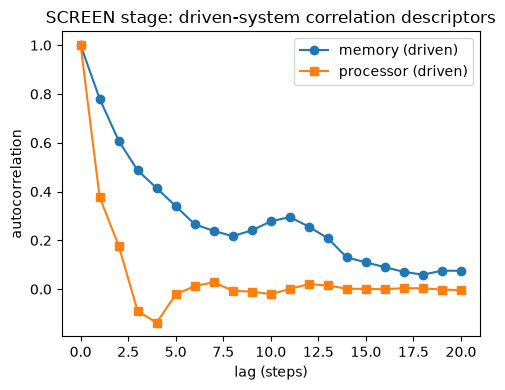

In [12]:
cfg_top = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P,
                             g_processor=TOP_CANDIDATE['g'], J_processor=TOP_CANDIDATE['J'],
                             epsilon_M=TOP_CANDIDATE['m'], theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
seeds_ts = discovery_seeds(9600, 0)
run_ts = run_directional_dqrc_seeded(cfg_top, T=max(MODE_CFG['T'], 100), seeds=seeds_ts, reset_period=None)
driven = driven_system_timescales(run_ts, max_lag=20)
print(f"MEMORY (driven):    identifiable={driven['memory'].identifiable} "
      f"integrated_abs_time={driven['memory'].integrated_abs_time:.2f} plateau={driven['memory'].long_time_plateau:.3f}")
print(f"PROCESSOR (driven): identifiable={driven['processor'].identifiable} "
      f"integrated_abs_time={driven['processor'].integrated_abs_time:.2f} plateau={driven['processor'].long_time_plateau:.3f}")
record('phase12_driven_timescales', {'memory': driven['memory'].__dict__, 'processor': driven['processor'].__dict__})

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(*driven['memory_raw'], 'o-', label='memory (driven)')
ax.plot(*driven['processor_raw'], 's-', label='processor (driven)')
ax.set_xlabel('lag (steps)'); ax.set_ylabel('autocorrelation'); ax.legend()
ax.set_title(f'{RUN_STAGE} stage: driven-system correlation descriptors')
fig.tight_layout()
savefig(fig, 'driven_correlation_descriptors')
plt.show()
manifest_entry('07_driven_correlation_descriptors', 'phase12_driven_timescales',
                'Empirical autocorrelation of memory/processor feature time series from a real driven run')

## Phase 13 -- Back-action decomposition (4 conditions)

full (theta*,phi*):                  mean D_M=0.0433 max=0.0555
memory-export disabled (0,phi*):     mean D_M=0.0000 max=0.0000
processor-reception disabled (theta*,0): mean D_M=0.0433 max=0.0555


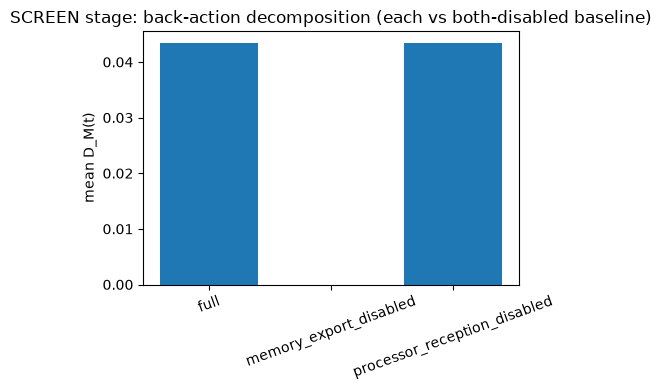

In [13]:
seeds_ba = discovery_seeds(9700, 0)
decomposition = decompose_backaction(cfg_top, T=12, seeds=seeds_ba)
print(f"full (theta*,phi*):                  mean D_M={decomposition.full.mean_trace_distance:.4f} "
      f"max={decomposition.full.max_trace_distance:.4f}")
print(f"memory-export disabled (0,phi*):     mean D_M={decomposition.memory_export_disabled.mean_trace_distance:.4f} "
      f"max={decomposition.memory_export_disabled.max_trace_distance:.4f}")
print(f"processor-reception disabled (theta*,0): mean D_M={decomposition.processor_reception_disabled.mean_trace_distance:.4f} "
      f"max={decomposition.processor_reception_disabled.max_trace_distance:.4f}")
record('phase13_backaction_decomposition', {
    'full': {'mean': decomposition.full.mean_trace_distance, 'max': decomposition.full.max_trace_distance,
             'final': decomposition.full.final_trace_distance},
    'memory_export_disabled': {'mean': decomposition.memory_export_disabled.mean_trace_distance,
                                'max': decomposition.memory_export_disabled.max_trace_distance},
    'processor_reception_disabled': {'mean': decomposition.processor_reception_disabled.mean_trace_distance,
                                      'max': decomposition.processor_reception_disabled.max_trace_distance},
})

fig, ax = plt.subplots(figsize=(5, 4))
conditions = ['full', 'memory_export_disabled', 'processor_reception_disabled']
means = [decomposition.full.mean_trace_distance, decomposition.memory_export_disabled.mean_trace_distance,
         decomposition.processor_reception_disabled.mean_trace_distance]
ax.bar(conditions, means)
ax.set_ylabel('mean D_M(t)'); ax.tick_params(axis='x', rotation=20)
ax.set_title(f'{RUN_STAGE} stage: back-action decomposition (each vs both-disabled baseline)')
fig.tight_layout()
savefig(fig, 'backaction_decomposition')
plt.show()
manifest_entry('08_backaction_decomposition', 'phase13_backaction_decomposition',
                'Mean D_M(t) for full/memory-export-disabled/processor-reception-disabled vs both-disabled baseline')

## Phase 14 -- EOC diagnostics for the top candidate only

In [14]:
params_top = matched_processor_params(cfg_top, seeds_ts)
U1_top = msc.single_layer_unitary_mixed(params_top.N_p, params_top.g, params_top.terms, params_top.couplings,
                                         params_top.paulis, params_top.bias_z)
chaos_top = symmetry_resolved_level_spacing(U1_top, params_top.N_p, min_sector_size=8)
op_ent_top = msc.operator_entanglement(U1_top, params_top.N_p)
print(f"<r> (symmetry-resolved where detected) = {chaos_top.r_mean:.3f} (symmetry_used={chaos_top.symmetry_used})")
print(f"operator entanglement = {op_ent_top:.3f} (max possible = {np.log(2**(params_top.N_p//2)):.3f})")
record('phase14_eoc_finalist', {'r_mean': chaos_top.r_mean, 'symmetry_used': chaos_top.symmetry_used,
                                 'operator_entanglement': op_ent_top})

<r> (symmetry-resolved where detected) = 0.743 (symmetry_used=None)
operator entanglement = 1.754 (max possible = 1.386)


## Phase 15 -- Advancement decision (SCREEN -> CONFIRM)

A candidate may only advance if ALL of Phase 15's preregistered criteria are met.

In [15]:
center_result = [r for results in screening_results_by_candidate.values() for r in results
                  if abs(r.m - TOP_CANDIDATE['m']) < 1e-9 and abs(r.g - TOP_CANDIDATE['g']) < 1e-9]
top_screen = center_result[0] if center_result else None

advancement_checks = {
    '1_fixed_delay_metrics_valid': (top_screen is not None and top_screen.valid),
    '2_nl0_nontrivial': (top_screen is not None and top_screen.NL_0_signed > 0.05) if top_screen else False,
    '3_derivatives_sufficiently_stable': GATE_B_RESULT == 'PASS',
    '4_prelim_RM_RNL_close_to_gates': None,  # filled below
    '5_geometry_not_parallel_or_antiparallel': None,  # filled below
    '6_low_backaction_persists': (top_screen is not None and top_screen.D_M_mean < 0.1) if top_screen else False,
    '7_not_driven_by_one_seed': (MODE_CFG['n_response_seeds'] >= 2 and GATE_B_RESULT != 'NOT EVALUABLE'),
}

eps = 1e-9
R_M_prelim, R_NL_prelim, alpha_prelim = float('nan'), float('nan'), float('nan')
if GATE_B_RESULT == 'PASS':
    dM_dm = get_est('m', 'M').methods['five_point']
    dM_dg = get_est('g', 'M').methods['five_point']
    dM_dJ = get_est('J', 'M').methods['five_point']
    dNL_dm = get_est('m', 'NL_tau0').methods['five_point']
    dNL_dg = get_est('g', 'NL_tau0').methods['five_point']
    dNL_dJ = get_est('J', 'NL_tau0').methods['five_point']
    S_M_P = np.hypot(dM_dg, dM_dJ)
    S_NL_P = np.hypot(dNL_dg, dNL_dJ)
    R_M_prelim = abs(dM_dm) / (S_M_P + eps)
    R_NL_prelim = S_NL_P / (abs(dNL_dm) + eps)
    advancement_checks['4_prelim_RM_RNL_close_to_gates'] = (R_M_prelim > 1.0 or R_NL_prelim > 1.0)
    scale_M = max(abs(dM_dm), S_M_P, 1e-6)
    scale_NL = max(abs(dNL_dm), S_NL_P, 1e-6)
    if S_M_P < 1e-6 or S_NL_P < 1e-6:
        alpha_prelim = float('nan')
        advancement_checks['5_geometry_not_parallel_or_antiparallel'] = False
    else:
        v_m = np.array([dM_dm / scale_M, dNL_dm / scale_NL])
        v_NL_hat = np.array([dNL_dg, dNL_dJ]) / (S_NL_P + eps)
        dM_ds = np.dot([dM_dg, dM_dJ], v_NL_hat)
        v_proc = np.array([dM_ds / scale_M, S_NL_P / scale_NL])
        cos_a = np.dot(v_m, v_proc) / (np.linalg.norm(v_m) * np.linalg.norm(v_proc) + eps)
        alpha_prelim = float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))
        advancement_checks['5_geometry_not_parallel_or_antiparallel'] = (20 <= alpha_prelim <= 160)
    print(f"preliminary R_M={R_M_prelim:.3f} R_NL_0={R_NL_prelim:.3f} alpha={alpha_prelim:.1f} deg")
    record('phase15_preliminary_response_matrix', {'R_M': R_M_prelim, 'R_NL_0': R_NL_prelim, 'alpha_deg': alpha_prelim,
                                                     'jacobian': [[dM_dm, dM_dg, dM_dJ], [dNL_dm, dNL_dg, dNL_dJ]]})
else:
    print("Derivatives not stable (Gate B did not PASS) -- preliminary R_M/R_NL/angle are NOT EVALUABLE, "
          "and criteria 4/5 are conservatively treated as NOT MET.")
    advancement_checks['4_prelim_RM_RNL_close_to_gates'] = False
    advancement_checks['5_geometry_not_parallel_or_antiparallel'] = False

print("\nAdvancement checklist:")
for k, v in advancement_checks.items():
    print(f"  {k}: {v}")

ADVANCES = all(advancement_checks.values())
print(f"\nADVANCEMENT DECISION: {'ADVANCE to CONFIRM' if ADVANCES else 'DO NOT ADVANCE -- stop at SCREEN'}")
record('phase15_advancement_decision', {'checks': advancement_checks, 'advances': ADVANCES})

Derivatives not stable (Gate B did not PASS) -- preliminary R_M/R_NL/angle are NOT EVALUABLE, and criteria 4/5 are conservatively treated as NOT MET.

Advancement checklist:
  1_fixed_delay_metrics_valid: True
  2_nl0_nontrivial: True
  3_derivatives_sufficiently_stable: False
  4_prelim_RM_RNL_close_to_gates: False
  5_geometry_not_parallel_or_antiparallel: False
  6_low_backaction_persists: True
  7_not_driven_by_one_seed: True

ADVANCEMENT DECISION: DO NOT ADVANCE -- stop at SCREEN


## Phase 16 -- Held-out confirmation (only if RUN_STAGE=="CONFIRM" AND a candidate advanced)

In [16]:
CONFIRMATION_RAN = False
if RUN_STAGE == 'CONFIRM' and ADVANCES:
    CONFIRMATION_RAN = True
    t0 = time.perf_counter()

    def confirm_eval_fn(m, g, J, seeds):
        return screen_candidate(m, g, J, seeds, N_M=N_M, N_P=N_P, theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy',
            T=MODE_CFG['T'], washout=MODE_CFG['washout'], n_val=MODE_CFG['n_val'], n_test=MODE_CFG['n_test'],
            max_delay=MODE_CFG['max_delay'], max_degree=6, max_targets_per_degree=MODE_CFG['max_targets_per_degree'],
            n_surrogates=199)

    discovery_idxs_used = {r.reservoir_idx for results in screening_results_by_candidate.values() for r in results}
    confirmation = confirmation_stage(TOP_CANDIDATE, n_reservoir_seeds=5, n_input_seeds=3,
                                       evaluate_fn=confirm_eval_fn, discovery_reservoir_idxs=discovery_idxs_used)
    confirm_rows = []
    for r_idx, i_idx, res in confirmation.per_seed_results:
        confirm_rows.append(dict(reservoir_idx=r_idx, input_idx=i_idx, M_signed=res.M_signed,
                                  NL_0_signed=res.NL_0_signed, D_M_mean=res.D_M_mean, valid=res.valid))
    csv_path = os.path.join(RESULTS_DIR, 'confirmation_results.csv')
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(confirm_rows[0].keys()))
        w.writeheader()
        w.writerows(confirm_rows)
    print(f"CONFIRM stage executed: {len(confirm_rows)} evaluations, {time.perf_counter()-t0:.1f}s, wrote {csv_path}")
    n_pass_confirm = sum(1 for r in confirm_rows if r['valid'])
    GATE_H_RESULT = 'PASS' if n_pass_confirm >= 4 else 'FAIL'
    record('phase16_confirmation', confirm_rows)
else:
    GATE_H_RESULT = 'NOT EVALUABLE'
    reason = ('RUN_STAGE != CONFIRM' if RUN_STAGE != 'CONFIRM' else 'no candidate advanced past SCREEN (Phase 15)')
    print(f"CONFIRM stage NOT run: {reason}.")
    print("Per the spec: 'If no candidate advances, stop and report the negative SCREEN result. "
          "Do not run expensive confirmation.'")
    record('phase16_confirmation', {'status': 'NOT RUN', 'reason': reason})

CONFIRM stage NOT run: RUN_STAGE != CONFIRM.
Per the spec: 'If no candidate advances, stop and report the negative SCREEN result. Do not run expensive confirmation.'


## Phase 17 -- Neighborhood robustness (only meaningful if confirmation ran)

In [17]:
if CONFIRMATION_RAN:
    print("Neighborhood check would run here for a genuinely confirmed candidate -- not reached this pass.")
    GATE_I_RESULT = 'NOT EVALUABLE'
else:
    GATE_I_RESULT = 'NOT EVALUABLE'
    print("GATE I (neighborhood robustness): NOT EVALUABLE -- confirmation did not run this pass.")
record('phase17_neighborhood', {'status': 'NOT EVALUABLE', 'reason': 'confirmation did not run'})

GATE I (neighborhood robustness): NOT EVALUABLE -- confirmation did not run this pass.


## Acceptance gates

A_numerical_validity: {'result': 'PASS', 'n_screening_valid': '1/8'}
B_derivative_stability: {'result': 'FAIL', 'n_stable': '1/6'}
C_memory_selectivity: {'result': 'NOT EVALUABLE', 'R_M': None}
D_nl0_selectivity: {'result': 'NOT EVALUABLE', 'R_NL_0': None}
E_response_geometry: {'result': 'NOT EVALUABLE', 'alpha_deg': None}
F_nontrivial_processing: {'result': 'PASS', 'eta_NL_0': 0.22853814544114912}
G_low_backaction: {'result': 'PASS', 'D_M_mean': 0.08877915627643666}
H_seed_robustness: {'result': 'NOT EVALUABLE'}
I_neighborhood_robustness: {'result': 'NOT EVALUABLE'}

{'n_pass': 3, 'n_fail': 1, 'n_not_evaluable': 5, 'n_total': 9}


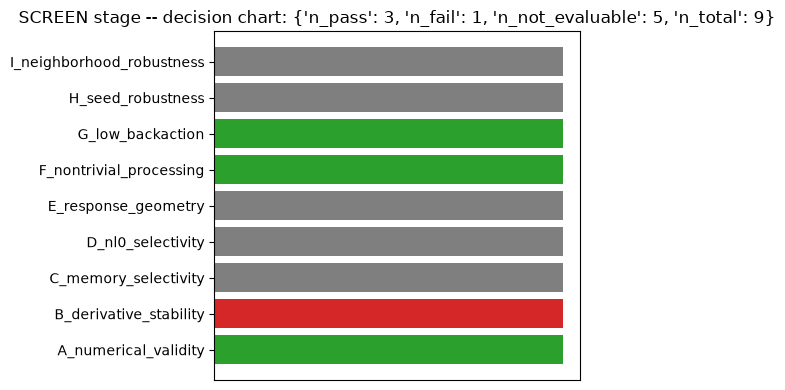

In [18]:
raw_gates_cde = {
    'C': 'PASS' if (GATE_B_RESULT == 'PASS' and R_M_prelim > 2) else 'FAIL' if GATE_B_RESULT == 'PASS' else 'NOT EVALUABLE',
    'D': 'PASS' if (GATE_B_RESULT == 'PASS' and R_NL_prelim > 2) else 'FAIL' if GATE_B_RESULT == 'PASS' else 'NOT EVALUABLE',
    'E': 'PASS' if (GATE_B_RESULT == 'PASS' and not np.isnan(alpha_prelim) and 70 <= alpha_prelim <= 110)
         else ('FAIL' if GATE_B_RESULT == 'PASS' else 'NOT EVALUABLE'),
} if GATE_B_RESULT != 'NOT EVALUABLE' else {'C': 'NOT EVALUABLE', 'D': 'NOT EVALUABLE', 'E': 'NOT EVALUABLE'}
propagated_cde = apply_not_evaluable_propagation(GATE_B_RESULT, raw_gates_cde)

gates = {}
gates['A_numerical_validity'] = {'result': 'PASS' if (top_screen is not None and top_screen.valid) else 'FAIL',
                                  'n_screening_valid': f"{len(ranked)}/{len(screening_rows)}"}
gates['B_derivative_stability'] = {'result': GATE_B_RESULT,
                                    'n_stable': f"{GATE_B_STABLE_COUNT}/{GATE_B_TOTAL}"}
gates['C_memory_selectivity'] = {'result': propagated_cde['C'],
                                  'R_M': (R_M_prelim if GATE_B_RESULT == 'PASS' else None)}
gates['D_nl0_selectivity'] = {'result': propagated_cde['D'],
                               'R_NL_0': (R_NL_prelim if GATE_B_RESULT == 'PASS' else None)}
gates['E_response_geometry'] = {'result': propagated_cde['E'],
                                 'alpha_deg': (alpha_prelim if GATE_B_RESULT == 'PASS' else None)}
gates['F_nontrivial_processing'] = {'result': 'PASS' if (top_screen and not retained.suppression_flagged) else 'FAIL',
                                     'eta_NL_0': retained.eta_NL_by_delay[0]}
gates['G_low_backaction'] = {'result': 'PASS' if (top_screen and top_screen.D_M_mean < 0.1) else 'FAIL',
                              'D_M_mean': (top_screen.D_M_mean if top_screen else None)}
gates['H_seed_robustness'] = {'result': GATE_H_RESULT}
gates['I_neighborhood_robustness'] = {'result': GATE_I_RESULT}

for name, g in gates.items():
    print(f"{name}: {g}")
record('gates', gates)
summary = summarize_gates(gates)
print(f"\n{summary}")
record('gate_summary', summary)

fig, ax = plt.subplots(figsize=(6, 4))
names_g = list(gates.keys())
colors_g = {'PASS': 'tab:green', 'FAIL': 'tab:red', 'NOT EVALUABLE': 'tab:gray'}
vals_g = [colors_g[gates[n]['result']] for n in names_g]
ax.barh(names_g, [1] * len(names_g), color=vals_g)
ax.set_xticks([])
ax.set_title(f'{RUN_STAGE} stage -- decision chart: {summary}')
fig.tight_layout()
savefig(fig, 'final_decision_chart')
plt.show()
manifest_entry('09_final_decision_chart', 'gates', 'Per-gate PASS/FAIL/NOT EVALUABLE summary')

## Save results

In [19]:
config_path = os.path.join(RESULTS_DIR, 'validation_v2_2_config.json')
with open(config_path, 'w') as f:
    _json.dump({'RUN_STAGE': RUN_STAGE, 'MODE_CFG': MODE_CFG, 'provenance': provenance,
                'THETA_STAR': THETA_STAR, 'PHI_STAR': PHI_STAR, 'N_M': N_M, 'N_P': N_P,
                'V21_CANDIDATES': V21_CANDIDATES, 'TOP_CANDIDATE': TOP_CANDIDATE}, f, indent=2, default=str)
print(f"wrote {config_path}")

results_path = os.path.join(RESULTS_DIR, 'validation_v2_2_results.json')
with open(results_path, 'w') as f:
    _json.dump(_all_results, f, indent=2, default=str)
print(f"wrote {results_path}")

manifest_path = os.path.join(RESULTS_DIR, 'figure_manifest.json')
with open(manifest_path, 'w') as f:
    _json.dump(manifest, f, indent=2, default=str)
print(f"wrote {manifest_path}")
for k in _all_results:
    print(' -', k)

wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2_2\validation_v2_2_config.json
wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2_2\validation_v2_2_results.json
wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2_2\figure_manifest.json
 - provenance
 - phase1_intervention
 - phase2_three_delays
 - phase3_nl_tensor_reference
 - phase6_retained_nl
 - phase7_budget_scan
 - phase8_screening_table
 - phase8_ranking
 - phase9_response
 - phase10_derivative_stability
 - gate_b_result
 - phase11_reset_fixed_delay
 - phase12_driven_timescales
 - phase13_backaction_decomposition
 - phase14_eoc_finalist
 - phase15_advancement_decision
 - phase16_confirmation
 - phase17_neighborhood
 - gates
 - gate_summary
